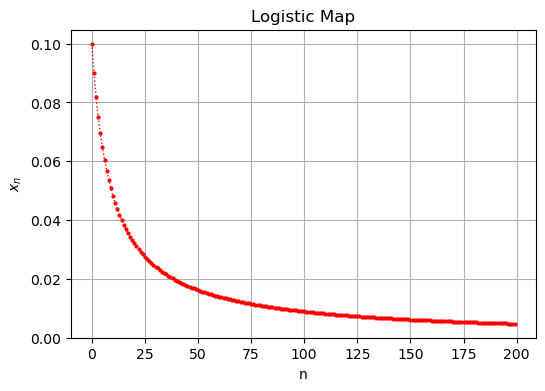

In [3]:
import tkinter as tk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt
import numpy as np

def plot_curve():
    try:
        r = float(entry_r.get())
        x0 = float(entry_x0.get())
        n = int(entry_n.get())

        if not (0 < x0 < 1):
            result_label.config(text="x₀ must be between 0 and 1")
            return
        if n < 1:
            result_label.config(text="n must be > 0")
            return

        x_val = np.zeros(n)
        x_val[0] = x0

        for i in range(n - 1):
            x_val[i + 1] = r * x_val[i] * (1 - x_val[i])

        ax.clear()
        ax.plot(range(n), x_val, 'o', linestyle='dotted', color='r', linewidth=1, markersize=2)
        ax.set_title("Logistic Map")
        ax.set_xlabel("n")
        ax.set_ylabel("$x_n$")
        ax.grid(True)
        canvas.draw()
        result_label.config(text="")

    except ValueError:
        result_label.config(text="Please enter valid numeric inputs.")

def clear():
    ax.clear()
    canvas.draw()
    result_label.config(text="")

root = tk.Tk()
root.title("Logistic Map Plotter")

tk.Label(root, text="r:").grid(row=0, column=0)
entry_r = tk.Entry(root)
entry_r.insert(0, "3.5")
entry_r.grid(row=0, column=1)

tk.Label(root, text="x₀:").grid(row=1, column=0)
entry_x0 = tk.Entry(root)
entry_x0.insert(0, "0.2")
entry_x0.grid(row=1, column=1)

tk.Label(root, text="n:").grid(row=2, column=0)
entry_n = tk.Entry(root)
entry_n.insert(0, "200")
entry_n.grid(row=2, column=1)

plot_button = tk.Button(root, text="Plot", command=plot_curve)
plot_button.grid(row=3, column=0, columnspan=2, pady=5)

clear_button = tk.Button(root, text="Clear", command=clear)
clear_button.grid(row=4, column=0, columnspan=2, pady=5)

result_label = tk.Label(root, text="", fg="red")
result_label.grid(row=5, column=0, columnspan=2)

fig, ax = plt.subplots(figsize=(6, 4))
canvas = FigureCanvasTkAgg(fig, master=root)
canvas.get_tk_widget().grid(row=0, column=2, rowspan=6, padx=10, pady=5)

# Run GUI
root.mainloop()
